# 제조 불량 리포트 & QA 데이터 탐색
- `reports_small.json` : 50건 (불량 보고서)
- `reports.json` : 150건 (불량 보고서)
- `qa_pairs.json` : 600건 (TYPE-A~D × 150 QA쌍)

In [15]:
import json
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "NanumGothic"  # 한글 폰트 - Colab에서 안 보이면 아래 셀로 설치
plt.rcParams["axes.unicode_minus"] = False


In [31]:
# Colab에서 한글 폰트가 깨질 경우 아래 주석 해제 후 실행, 런타임 재시작 필요
!apt-get -qq install fonts-nanum
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'


Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [16]:
import pandas as pd
import json
import urllib.request

BASE = 'https://raw.githubusercontent.com/ws-l/hh_2026_5/main/data/'

def load_json(url):
    with urllib.request.urlopen(url) as r:
        return json.load(r)

df_rep = pd.DataFrame(load_json(BASE + 'reports.json'))
df_qa  = pd.DataFrame(load_json(BASE + 'qa_pairs.json'))

print('reports :', df_rep.shape)
print('qa_pairs:', df_qa.shape)

reports : (150, 6)
qa_pairs: (600, 5)


## 1. reports.json 기본 탐색

In [17]:
df_rep.head()

,report_id,설비종류,불량유형,4M_분류,심각도,report_text
0,RPT-001,CNC 머신,치수불량,Machine,상,"2024년 1월 3일 09:15, CNC 머신 A-1호기에서 가공 완료된 알루미늄 ..."
1,RPT-002,CNC 머신,표면결함-스크래치/크랙,Machine,중,"2024년 1월 5일 14:30, CNC 머신 A-2호기에서 스테인리스 커버 외곽 ..."
2,RPT-003,CNC 머신,조립불량,Man,하,"2024년 1월 8일 10:45, CNC 머신 B-1호기 가공 후 조립된 베이스 플..."
3,RPT-004,사출성형기,표면결함-스크래치/크랙,Machine,상,"2024년 1월 10일 16:20, 사출성형기 #1호기에서 ABS 하우징 표면 게이..."
4,RPT-005,CNC 머신,치수불량,Man,중,"2024년 1월 12일 08:50, CNC 머신 A-3호기에서 기어 하우징 포켓 깊..."


In [18]:
df_rep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   report_id    150 non-null    object
 1   설비종류         150 non-null    object
 2   불량유형         150 non-null    object
 3   4M_분류        150 non-null    object
 4   심각도          150 non-null    object
 5   report_text  150 non-null    object
dtypes: object(6)
memory usage: 7.2+ KB


In [19]:
# 결측치 확인
df_rep.isnull().sum()

,0
report_id,0
설비종류,0
불량유형,0
4M_분류,0
심각도,0
report_text,0


In [20]:
# 범주형 컬럼 분포
for col in ['설비종류', '불량유형', '4M_분류', '심각도']:
    print(f'\n[{col}]')
    print(df_rep[col].value_counts())


[설비종류]
설비종류
용접기        25
프레스기       25
포장기        25
사출성형기      22
CNC 머신     18
컨베이어 벨트    15
CNC머신      10
컨베이어벨트     10
Name: count, dtype: int64

[불량유형]
불량유형
치수불량            30
표면결함-스크래치/크랙    28
조립불량            27
이물질혼입           27
누설              19
변색              19
Name: count, dtype: int64

[4M_분류]
4M_분류
Man         54
Method      44
Machine     30
Material    22
Name: count, dtype: int64

[심각도]
심각도
상    61
중    48
하    41
Name: count, dtype: int64


In [21]:
# report_text 길이 분포
df_rep['text_len'] = df_rep['report_text'].str.len()
df_rep['text_len'].describe()

,text_len
count,150.000000
mean,300.106667
std,15.076604
min,267.000000
25%,289.000000
50%,300.000000
75%,310.000000
max,343.000000


/tmp/ipykernel_3337/585457947.py:12: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3337/585457947.py:12: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3337/585457947.py:12: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3337/585457947.py:12: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3337/585457947.py:12: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3337/585457947.py:12: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3337/585457947.py:12: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layo

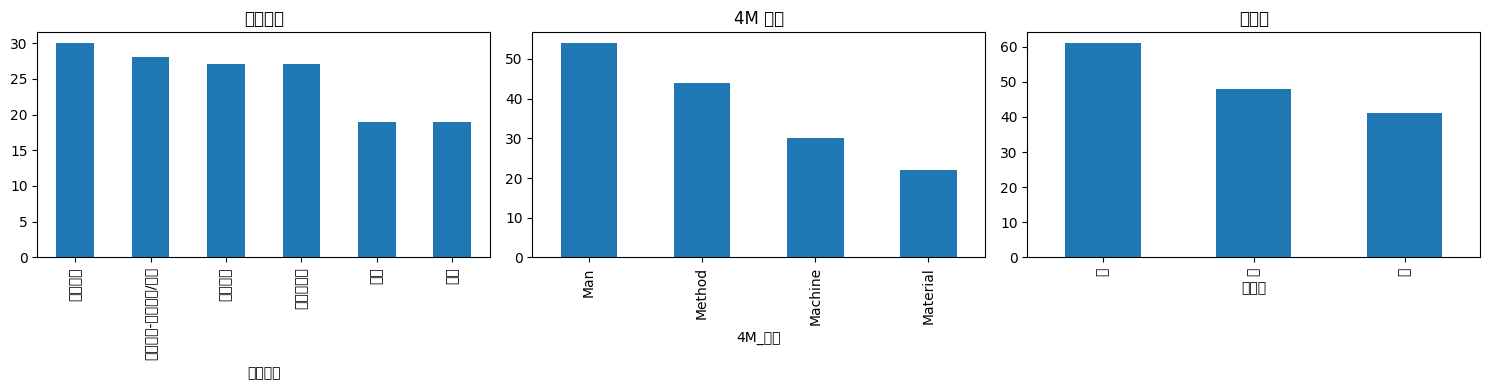

In [22]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'NanumGothic'   # 한글 폰트 (없으면 AppleGothic 등으로 변경)
matplotlib.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df_rep['불량유형'].value_counts().plot(kind='bar', ax=axes[0], title='불량유형')
df_rep['4M_분류'].value_counts().plot(kind='bar', ax=axes[1], title='4M 분류')
df_rep['심각도'].value_counts().reindex(['상','중','하']).plot(kind='bar', ax=axes[2], title='심각도')

plt.tight_layout()
plt.show()

In [23]:
# 4M × 심각도 크로스탭
pd.crosstab(df_rep['4M_분류'], df_rep['심각도'], margins=True)

심각도,상,중,하,All
4M_분류,,,,
Machine,18,7,5,30
Man,14,18,22,54
Material,6,10,6,22
Method,23,13,8,44
All,61,48,41,150


## 2. qa_pairs.json 기본 탐색

In [24]:
df_qa.head(8)

,report_id,type,instruction,input,output
0,RPT-001,TYPE-A,CNC 머신 A-1호기에서 브래킷 홀 직경이 도면보다 크게 가공되고 스핀들 진동이 ...,,스핀들 베어링 마모로 인해 회전 흔들림이 증가한 것이 원인으로 판단됩니다. 이로 인...
1,RPT-001,TYPE-B,CNC 머신 A-1호기에서 홀 직경 치수오차가 반복된 상황에서 담당자는 어떤 조치를...,,스핀들 베어링 상태를 점검하고 베어링을 교체했습니다. 이후 런아웃을 재측정하고 시험...
2,RPT-001,TYPE-C,CNC 홀 직경 치수불량의 재발을 막기 위해 어떤 대책을 수립했는가?,,스핀들 진동이 0.12mm를 초과하면 즉시 설비보전팀에 점검을 요청하도록 기준을 등...
3,RPT-001,TYPE-D,CNC 머신에서 홀 직경이 반복적으로 커지고 스핀들 진동이 높다면 어떤 가능성을 먼...,,스핀들 베어링 마모로 인한 런아웃 발생 가능성을 우선 점검해야 합니다. 특히 진동값...
4,RPT-002,TYPE-A,CNC 머신 A-2호기에서 스테인리스 커버 절삭면에 미세 스크래치가 발생했을 때 원...,,마모된 엔드밀의 절삭날이 소재 표면을 끌면서 스크래치를 유발한 것으로 추정됩니다. ...
5,RPT-002,TYPE-B,스테인리스 커버 외곽 절삭면에 스크래치가 발생한 경우 담당자는 어떤 조치를 했는가?,,해당 엔드밀을 교체하고 절삭유 분사 노즐을 청소했습니다. 이후 재가공품의 표면 거칠...
6,RPT-002,TYPE-C,CNC 공구 마모로 인한 스크래치 불량을 막기 위해 어떤 재발방지책을 세웠는가?,,공구 마모량이 0.35mm에 도달하면 자동 교체 알림이 발생하도록 설정했습니다. 공...
7,RPT-002,TYPE-D,CNC 절삭면에 길이 18~25mm 수준의 스크래치가 반복되면 어떤 가능성을 먼저 ...,,엔드밀 절삭날 마모 가능성을 먼저 확인해야 합니다. 절삭온도 상승과 공구 측면 마모...


In [25]:
print(df_qa['type'].value_counts())

# instruction / output 길이
df_qa['inst_len'] = df_qa['instruction'].str.len()
df_qa['out_len']  = df_qa['output'].str.len()
df_qa[['inst_len','out_len']].describe()

type
TYPE-A    150
TYPE-B    150
TYPE-C    150
TYPE-D    150
Name: count, dtype: int64


,inst_len,out_len
count,600.000000,600.000000
mean,42.601667,78.660000
std,4.871607,10.359695
min,31.000000,52.000000
25%,39.000000,72.000000
50%,42.000000,78.000000
75%,45.000000,85.000000
max,66.000000,112.000000


## 3. reports + qa_pairs 병합

In [26]:
# report_id 기준 병합 → 하나의 보고서에 QA 4건 붙음
df_merged = df_qa.merge(df_rep, on='report_id', how='left')
print(df_merged.shape)
df_merged.head()

(600, 13)


,report_id,type,instruction,input,output,inst_len,out_len,설비종류,불량유형,4M_분류,심각도,report_text,text_len
0,RPT-001,TYPE-A,CNC 머신 A-1호기에서 브래킷 홀 직경이 도면보다 크게 가공되고 스핀들 진동이 ...,,스핀들 베어링 마모로 인해 회전 흔들림이 증가한 것이 원인으로 판단됩니다. 이로 인...,66,96,CNC 머신,치수불량,Machine,상,"2024년 1월 3일 09:15, CNC 머신 A-1호기에서 가공 완료된 알루미늄 ...",325
1,RPT-001,TYPE-B,CNC 머신 A-1호기에서 홀 직경 치수오차가 반복된 상황에서 담당자는 어떤 조치를...,,스핀들 베어링 상태를 점검하고 베어링을 교체했습니다. 이후 런아웃을 재측정하고 시험...,52,91,CNC 머신,치수불량,Machine,상,"2024년 1월 3일 09:15, CNC 머신 A-1호기에서 가공 완료된 알루미늄 ...",325
2,RPT-001,TYPE-C,CNC 홀 직경 치수불량의 재발을 막기 위해 어떤 대책을 수립했는가?,,스핀들 진동이 0.12mm를 초과하면 즉시 설비보전팀에 점검을 요청하도록 기준을 등...,38,94,CNC 머신,치수불량,Machine,상,"2024년 1월 3일 09:15, CNC 머신 A-1호기에서 가공 완료된 알루미늄 ...",325
3,RPT-001,TYPE-D,CNC 머신에서 홀 직경이 반복적으로 커지고 스핀들 진동이 높다면 어떤 가능성을 먼...,,스핀들 베어링 마모로 인한 런아웃 발생 가능성을 우선 점검해야 합니다. 특히 진동값...,57,93,CNC 머신,치수불량,Machine,상,"2024년 1월 3일 09:15, CNC 머신 A-1호기에서 가공 완료된 알루미늄 ...",325
4,RPT-002,TYPE-A,CNC 머신 A-2호기에서 스테인리스 커버 절삭면에 미세 스크래치가 발생했을 때 원...,,마모된 엔드밀의 절삭날이 소재 표면을 끌면서 스크래치를 유발한 것으로 추정됩니다. ...,54,86,CNC 머신,표면결함-스크래치/크랙,Machine,중,"2024년 1월 5일 14:30, CNC 머신 A-2호기에서 스테인리스 커버 외곽 ...",291


In [27]:
# TYPE별 output 평균 길이
df_merged.groupby('type')['out_len'].mean().round(1)

,out_len
type,
TYPE-A,90.2
TYPE-B,67.1
TYPE-C,77.7
TYPE-D,79.7


In [28]:
# 심각도별 QA 수
df_merged.groupby(['심각도','type']).size().unstack(fill_value=0)

type,TYPE-A,TYPE-B,TYPE-C,TYPE-D
심각도,,,,
상,61,61,61,61
중,48,48,48,48
하,41,41,41,41


## 4. 샘플 QA 확인

In [29]:
# 특정 report_id의 QA 세트 전체 보기
sample_id = 'RPT-001'
for _, row in df_qa[df_qa['report_id'] == sample_id].iterrows():
    print(f"[{row['type']}] Q: {row['instruction']}")
    print(f"       A: {row['output']}")
    print()

[TYPE-A] Q: CNC 머신 A-1호기에서 브래킷 홀 직경이 도면보다 크게 가공되고 스핀들 진동이 높게 확인되었을 때 원인은 무엇인가?
       A: 스핀들 베어링 마모로 인해 회전 흔들림이 증가한 것이 원인으로 판단됩니다. 이로 인해 홀 가공 중 런아웃이 발생했고, 기준 홀 직경이 12.00mm보다 크게 측정되었습니다.

[TYPE-B] Q: CNC 머신 A-1호기에서 홀 직경 치수오차가 반복된 상황에서 담당자는 어떤 조치를 취했는가?
       A: 스핀들 베어링 상태를 점검하고 베어링을 교체했습니다. 이후 런아웃을 재측정하고 시험 가공품 5개의 홀 직경이 12.00±0.02mm 범위에 들어오는지 검증했습니다.

[TYPE-C] Q: CNC 홀 직경 치수불량의 재발을 막기 위해 어떤 대책을 수립했는가?
       A: 스핀들 진동이 0.12mm를 초과하면 즉시 설비보전팀에 점검을 요청하도록 기준을 등록했습니다. 진동값을 조기 관리하여 베어링 마모에 따른 런아웃을 예방하려는 대책입니다.

[TYPE-D] Q: CNC 머신에서 홀 직경이 반복적으로 커지고 스핀들 진동이 높다면 어떤 가능성을 먼저 점검해야 하는가?
       A: 스핀들 베어링 마모로 인한 런아웃 발생 가능성을 우선 점검해야 합니다. 특히 진동값이 관리 기준을 초과하는 경우 베어링 상태와 회전 흔들림을 확인하는 것이 적절합니다.

